# Banjul Cacao Factory (BDF)

## 1. Inleiding

De Banjul Cacao Factory (BCF) is een cacaofabriek in Gambia die grotendeels werkt met verouderde machines en handmatige productieprocessen. Dit draagt bij aan een vergroot risico op storingen en defecte machines, waardoor de productie (tijdelijk) stil komt te liggen. Daar komt bovenop dat de fabriek te maken heeft met een instabiele stroomvoorziening. Stroomuitval komt regelmatig voor en kan ervoor zorgen dat de productie meerdere uren stil komt te liggen. Hiervoor maakt BCF gebruik van dieselgeneratoren, maar deze brengen hoge energiekosten met zich mee en zetten daardoor de financiële positie van het bedrijf onder druk.

Binnen deze context richten wij ons op het probleem van het onvoorspelbare defectpercentage. Hiervoor heeft BCF nog geen voorspellende analyses, waardoor zij niet tijdig kan anticiperen op een hoog percentage defecte producten (welk percentage van de geproduceerde cacao niet aan de kwaliteitseisen voldoet) en onnodige verspilling het gevolg is.

Binnen dit datavraagstuk zal via Python-programmeren het defectpercentage (target) worden voorspeld aan de hand van de volgende features: verlooppercentage (%), medewerkerstevredenheid (1-50), trainingstijden (uren) en productie (kg). Hierbij gaat het om een regressieprobleem, omdat de variabele die we willen voorspellen een continue numerieke waarde is. Het defectpercentage vormt daarmee de targetvariabele van het model.

De uitkomst van het model kan vervolgens in de praktijk worden gebruikt om vroegtijdig bij te sturen op personeelsbeleid. Het model kan vooraf inschatten in welke periodes het defectpercentage zal oplopen en op die manier kunnen vroegtijdig trainingen worden ingepland en tevredenheidsproblemen worden aangepakt. Daarnaast kunnen de schaarse middelen die BCF beschikbaar heeft voor trainingen met behulp van het probleem zo efficiënt mogelijk worden ingezet.

De features medewerkerstevredenheid en trainingstijd zijn geselecteerd op basis van correlatie. De features energieverbruik en productie hebben geen sterke correlatie, maar worden toch gebruikt omdat veel productie samengaat met een hoge werkdruk en meer kans op fouten. Verlooppercentage heeft invloed op de ervaring van de medewerkers en daarmee op de hoeveelheid foute productie en zal dus ook als feature worden meegenomen.

De voorspelling zelf voorkomt niet rechtstreeks een hoog defectpercentage, maar geeft BCF wel de informatie om eerder maatregelen te nemen en daarmee het defectpercentage te verkleinen.

## 2. Data inladen


**Inleiding hoofdstuk**

### 2.1 Imports (libraries)

In [20]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



### 2.2 Datasets inlezen

In [21]:
data_dir = Path("data")

dataframes = {}
for file in data_dir.glob("*.csv"):
    naam = re.sub(r"\W", "_", file.stem)   # alleen letters/cijfers/underscore
    if naam[0].isdigit():
        naam = f"_{naam}"

    df = pd.read_csv(file)
    dataframes[naam] = df
    globals()[naam] = df  # maakt bv. bcf_boeren_data_adjusted als losse variabele

print(list(dataframes.keys()))

['bcf_boeren_data_adjusted', 'bcf_financieel_overzicht_adjusted', 'bcf_hr_training_varied', 'bcf_kwaliteit_klanttevredenheid_varied', 'bcf_omgeving_data_adjusted', 'bcf_productie_duurzaamheid_adjusted']


In [22]:
# Display all dataframes below eachother

for name, df in dataframes.items():
    print(f"Dataframe: {name}")
    display(df)
    

Dataframe: bcf_boeren_data_adjusted


,Boer_ID,Irrigatie_toegang (0-3)
0,Boer_60,1
1,Boer_60,1
2,Boer_60,3
3,Boer_60,3
4,Boer_60,1
5,Boer_60,3
6,Boer_60,2
7,Boer_60,0
8,Boer_60,2
9,Boer_60,0


Dataframe: bcf_financieel_overzicht_adjusted


,Datum,Productie (kg),Opbrengst boeren (kg),Energieverbruik (kWh),CO2-uitstoot (kg),Omzet (€),Kosten (€),Winst (€),ROI (%)
0,2022-01-01,19943,1163,2241.0,2140.0,51957.0,30859.0,21098.0,68.37
1,2022-01-31,22910,1109,3979.0,3595.0,89859.0,30161.0,59698.0,197.93
2,2022-03-02,20558,2569,2731.0,2503.0,60941.0,41912.0,19029.0,45.40
3,2022-04-01,23025,1836,4020.0,3633.0,85052.0,27251.0,57801.0,212.11
4,2022-05-01,30066,1373,7021.0,5309.0,75989.0,45331.0,30658.0,67.63
5,2022-05-31,25762,2718,3016.0,2352.0,90577.0,52777.0,37800.0,71.62
6,2022-06-30,22284,2703,3227.0,2879.0,59283.0,29318.0,29965.0,102.21
7,2022-07-30,21040,2892,5484.0,4645.0,54429.0,40188.0,14241.0,35.44
8,2022-08-29,19953,2525,2888.0,2264.0,75167.0,32930.0,42237.0,128.26
9,2022-09-28,19989,1750,5914.0,4299.0,69503.0,25243.0,44260.0,175.34


Dataframe: bcf_hr_training_varied


...

,Datum,Klanttevredenheid (1-10),Klantloyaliteit (1-10),Aantal klachten
0,2022-01-01,10.0,9.2,2
1,2022-01-31,6.1,4.9,34
2,2022-03-02,8.5,7.2,15
3,2022-04-01,9.8,10.0,2
4,2022-05-01,10.0,5.7,9
5,2022-05-31,10.0,10.0,0
6,2022-06-30,10.0,4.2,19
7,2022-07-30,9.5,6.2,3
8,2022-08-29,10.0,4.7,9
9,2022-09-28,10.0,8.2,4


Dataframe: bcf_omgeving_data_adjusted


,Datum,Totale opbrengst (kg),Regenval (mm),Bodemkwaliteit (1-10),Temperatuur (°C)
0,2022-01-01,127268.0,1210.6,6.7,26.6
1,2022-01-31,111562.0,1087.2,5.1,34.3
2,2022-03-02,122096.0,1521.2,6.2,15.9
3,2022-04-01,119853.0,1730.1,6.0,34.4
4,2022-05-01,125332.0,883.5,6.5,29.9
5,2022-05-31,125540.0,1700.7,6.5,28.3
6,2022-06-30,131302.0,1570.4,7.1,24.5
7,2022-07-30,127352.0,1370.6,6.7,16.1
8,2022-08-29,125933.0,867.0,6.6,18.4
9,2022-09-28,122795.0,1616.8,6.3,19.7


Dataframe: bcf_productie_duurzaamheid_adjusted


,Datum,Productie (kg),Trainingstijden (uren),Energieverbruik (kWh),CO2-uitstoot (kg),Kwaliteitsscore (1-10),Defectpercentage (%)
0,2022-01-01,19943,125.9,2241.0,2140.0,7.1,1.36
1,2022-01-31,22910,129.9,3979.0,3595.0,7.8,0.00
2,2022-03-02,20558,87.0,2731.0,2503.0,6.7,4.15
3,2022-04-01,23025,106.6,4020.0,3633.0,7.4,1.78
4,2022-05-01,30066,95.0,7021.0,5309.0,6.0,6.11
5,2022-05-31,25762,122.7,3016.0,2352.0,7.1,3.16
6,2022-06-30,22284,103.7,3227.0,2879.0,7.8,1.38
7,2022-07-30,21040,102.8,5484.0,4645.0,6.2,0.86
8,2022-08-29,19953,106.8,2888.0,2264.0,7.5,2.72
9,2022-09-28,19989,126.1,5914.0,4299.0,8.2,0.00


### 2.3 Eerste blik op de data

#### 2.3.1 Algemeen overzicht per dataset

Voor elk dataframe: vorm, datatypes, missende waarden en de eerste rijen.

In [23]:
for naam, df in dataframes.items():
    print(f"===== {naam} =====")
    print("Shape:", df.shape)
    print()
    print("Datatypes:")
    print(df.dtypes)
    print()
    print("Missende waarden per kolom:")
    print(df.isna().sum())
    print()
  

===== bcf_boeren_data_adjusted =====
Shape: (50, 2)

Datatypes:
Boer_ID                    object
Irrigatie_toegang (0-3)     int64
dtype: object

Missende waarden per kolom:
Boer_ID                    0
Irrigatie_toegang (0-3)    0
dtype: int64

===== bcf_financieel_overzicht_adjusted =====
Shape: (60, 9)

Datatypes:
Datum                     object
Productie (kg)             int64
Opbrengst boeren (kg)      int64
Energieverbruik (kWh)    float64
CO2-uitstoot (kg)        float64
Omzet (€)                float64
Kosten (€)               float64
Winst (€)                float64
ROI (%)                  float64
dtype: object

Missende waarden per kolom:
Datum                    0
Productie (kg)           0
Opbrengst boeren (kg)    0
Energieverbruik (kWh)    0
CO2-uitstoot (kg)        0
Omzet (€)                0
Kosten (€)               0
Winst (€)                0
ROI (%)                  0
dtype: int64

===== bcf_hr_training_varied =====
Shape: (60, 5)

Datatypes:
Datum                

#### 2.3.2 Beschrijvende statistiek per dataset

Ranges, gemiddeldes en spreiding van de numerieke kolommen — handig om uitschieters of onrealistische waarden op te sporen.

In [24]:
for naam, df in dataframes.items():
    print(f"===== {naam} =====")
    display(df.describe())

===== bcf_boeren_data_adjusted =====


,Irrigatie_toegang (0-3)
count,50.000000
mean,1.360000
std,1.120496
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,3.000000


===== bcf_financieel_overzicht_adjusted =====


,Productie (kg),Opbrengst boeren (kg),Energieverbruik (kWh),CO2-uitstoot (kg),Omzet (€),Kosten (€),Winst (€),ROI (%)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,25248.183333,2030.600000,4986.016667,4011.200000,78943.233333,40344.083333,38599.150000,101.553167
std,6905.996823,637.828233,1995.312248,1608.740362,25250.346553,12564.361605,18788.981591,53.119598
min,11366.000000,1039.000000,2077.000000,1482.000000,33950.000000,19167.000000,11398.000000,35.440000
25%,20783.000000,1517.250000,3305.500000,2682.500000,61070.000000,30822.750000,24888.750000,65.167500
50%,23575.500000,1887.000000,4936.500000,4025.500000,74815.500000,40289.000000,34371.000000,76.990000
75%,29695.750000,2703.000000,6112.750000,4926.000000,91463.750000,46094.750000,47370.250000,132.600000
max,43566.000000,2974.000000,10658.000000,8518.000000,167447.000000,84375.000000,87797.000000,230.910000


===== bcf_hr_training_varied =====


...

,Klanttevredenheid (1-10),Klantloyaliteit (1-10),Aantal klachten
count,60.000000,60.000000,60.000000
mean,9.186667,6.406667,12.116667
std,1.102919,1.705312,7.917138
min,6.100000,3.900000,0.000000
25%,8.575000,5.075000,5.000000
50%,9.850000,6.100000,11.000000
75%,10.000000,7.125000,17.500000
max,10.000000,10.000000,34.000000


===== bcf_omgeving_data_adjusted =====


,Totale opbrengst (kg),Regenval (mm),Bodemkwaliteit (1-10),Temperatuur (°C)
count,60.000000,60.000000,60.000000,60.000000
mean,123748.500000,1335.568333,6.346667,25.276667
std,6444.093621,291.367021,0.643209,5.886709
min,109308.000000,825.300000,4.900000,15.200000
25%,119561.000000,1104.000000,5.900000,20.050000
50%,123001.500000,1375.850000,6.300000,25.100000
75%,128154.500000,1569.425000,6.825000,30.550000
max,135543.000000,1800.100000,7.500000,34.900000


===== bcf_productie_duurzaamheid_adjusted =====


,Productie (kg),Trainingstijden (uren),Energieverbruik (kWh),CO2-uitstoot (kg),Kwaliteitsscore (1-10),Defectpercentage (%)
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,25248.183333,105.488333,4986.016667,4011.200000,7.066667,2.585833
std,6905.996823,24.850250,1995.312248,1608.740362,0.813377,2.100346
min,11366.000000,51.300000,2077.000000,1482.000000,5.300000,0.000000
25%,20783.000000,88.650000,3305.500000,2682.500000,6.400000,0.820000
50%,23575.500000,107.700000,4936.500000,4025.500000,7.150000,2.550000
75%,29695.750000,126.100000,6112.750000,4926.000000,7.625000,3.775000
max,43566.000000,146.900000,10658.000000,8518.000000,8.700000,9.400000


#### 2.3.3 Tijdsdekking van de tijdreeks-bestanden

Vijf van de zes bestanden hebben een `Datum`-kolom en zijn in principe op maandniveau te koppelen. We checken of ze dezelfde periode dekken, geen dubbele datums bevatten en dus veilig te mergen zijn. De boeren-data heeft geen `Datum` en laten we hier buiten beschouwing.

In [25]:
tijdreeks_bestanden = [n for n in dataframes if n != "bcf_boeren_data_adjusted"]

for naam in tijdreeks_bestanden:
    df = dataframes[naam]
    df["Datum"] = pd.to_datetime(df["Datum"])
    print(
        f"{naam}: {df['Datum'].min().date()} t/m {df['Datum'].max().date()}, "
        f"{df['Datum'].nunique()} unieke datums, {len(df)} rijen, "
        f"dubbele datums: {df['Datum'].duplicated().sum()}"
    )

bcf_financieel_overzicht_adjusted: 2022-01-01 t/m 2026-11-06, 60 unieke datums, 60 rijen, dubbele datums: 0
bcf_hr_training_varied: 2022-01-01 t/m 2026-11-06, 60 unieke datums, 60 rijen, dubbele datums: 0
bcf_kwaliteit_klanttevredenheid_varied: 2022-01-01 t/m 2026-11-06, 60 unieke datums, 60 rijen, dubbele datums: 0
bcf_omgeving_data_adjusted: 2022-01-01 t/m 2026-11-06, 60 unieke datums, 60 rijen, dubbele datums: 0
bcf_productie_duurzaamheid_adjusted: 2022-01-01 t/m 2026-11-06, 60 unieke datums, 60 rijen, dubbele datums: 0


#### 2.3.4 Uniciteit van de boeren-data

Deze dataset heeft geen `Datum`, maar een `Boer_ID`. We checken hoeveel unieke boeren er daadwerkelijk in zitten, en of `Irrigatie_toegang` genoeg spreiding heeft om als feature bruikbaar te zijn.

In [26]:
boeren = dataframes["bcf_boeren_data_adjusted"]

print("Aantal rijen:", len(boeren))
print("Aantal unieke Boer_ID's:", boeren["Boer_ID"].nunique())
print("Unieke waarden Boer_ID:", boeren["Boer_ID"].unique())
print("Verdeling Irrigatie_toegang:")
print(boeren["Irrigatie_toegang (0-3)"].value_counts())

Aantal rijen: 50
Aantal unieke Boer_ID's: 1
Unieke waarden Boer_ID: ['Boer_60']
Verdeling Irrigatie_toegang:
Irrigatie_toegang (0-3)
0    15
2    13
1    12
3    10
Name: count, dtype: int64


#### 2.3.5 Observaties eerste blik

Zelf samenvatten

## 3. Exploratory Data Analysis (EDA)

**Inleiding hoofdstuk**

### 3.1 Featurecorrelaties met target

In [27]:
# volgorde bepaalt welke versie van een dubbele kolom (bv. Productie, CO2-uitstoot)
# behouden blijft — productie_duurzaamheid staat eerst omdat daar ook de target in zit
bestanden = [
    "bcf_productie_duurzaamheid_adjusted.csv",
    "bcf_financieel_overzicht_adjusted.csv",
    "bcf_hr_training_varied.csv",
    "bcf_kwaliteit_klanttevredenheid_varied.csv",
    "bcf_omgeving_data_adjusted.csv",
]

merged = None
gezien_kolommen = {"Datum"}

for bestand in bestanden:
    df = pd.read_csv(data_dir / bestand, parse_dates=["Datum"])
    nieuwe_kolommen = ["Datum"] + [c for c in df.columns if c not in gezien_kolommen]
    df = df[nieuwe_kolommen]
    gezien_kolommen.update(nieuwe_kolommen)

    merged = df if merged is None else merged.merge(df, on="Datum", how="inner")

print(merged.shape)
print(merged.columns.tolist())

target = "Defectpercentage (%)"

correlatietabel = (
    merged.corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
    .rename("Correlatie")
    .reset_index()
    .rename(columns={"index": "Feature"})
)

correlatietabel

(60, 21)
['Datum', 'Productie (kg)', 'Trainingstijden (uren)', 'Energieverbruik (kWh)', 'CO2-uitstoot (kg)', 'Kwaliteitsscore (1-10)', 'Defectpercentage (%)', 'Opbrengst boeren (kg)', 'Omzet (€)', 'Kosten (€)', 'Winst (€)', 'ROI (%)', 'Medewerkerstevredenheid (1-50)', 'Verlooppercentage (%)', 'Klanttevredenheid (1-10)', 'Klantloyaliteit (1-10)', 'Aantal klachten', 'Totale opbrengst (kg)', 'Regenval (mm)', 'Bodemkwaliteit (1-10)', 'Temperatuur (°C)']


,Feature,Correlatie
0,Trainingstijden (uren),-0.644913
1,Medewerkerstevredenheid (1-50),-0.623864
2,Kwaliteitsscore (1-10),-0.603799
3,ROI (%),-0.170393
4,Klanttevredenheid (1-10),0.154460
5,Totale opbrengst (kg),-0.151171
6,Bodemkwaliteit (1-10),-0.151058
7,Verlooppercentage (%),0.146063
8,Winst (€),-0.132549
9,Temperatuur (°C),-0.110793


Op basis van bovenstaande correlatietabel zijn de features Trainingstijden (uren) en Medewerkerstevredenheid (1-50) geselecteerd als belangrijkste voorspellers van het defectpercentage, met correlatiewaarden van respectievelijk -0,64 en -0,62. Dit zijn de enige twee variabelen die boven de vuistregel van |r| > 0,5 uitkomen en daarmee een sterk statistisch verband met de target laten zien.

Kwaliteitsscore (1-10) is bewust buiten de featureset gehouden, ondanks een vergelijkbaar sterke correlatie van -0,60. Deze variabele is inhoudelijk vrijwel het spiegelbeeld van het defectpercentage en zou daardoor leiden tot datalekkage: het model zou de target dan indirect al kennen via een andere kolom, wat de voorspelling kunstmatig sterk maakt zonder dat dit in de praktijk bruikbaar is.

Productie (kg) en Verlooppercentage (%) laten een lage correlatie zien (tussen -0,17 en 0,15), maar worden desondanks getest als mogelijke features. Correlatie meet alleen lineaire, losstaande verbanden en niet eventuele interacties of niet-lineaire effecten, en deze variabelen zijn inhoudelijk logisch verbonden aan het verwerkingsproces waarin defecten ontstaan. 

Omgevingsdata (Regenval, Bodemkwaliteit, Temperatuur), financiële data (ROI, Winst, Omzet, Kosten) en klantdata (Klanttevredenheid, Klantloyaliteit, Aantal klachten) zijn niet meegenomen. Dit is niet enkel gebaseerd op de lage correlatie, maar ook op inhoudelijke overwegingen. Omgevingsdata heeft betrekking op de teeltfase bij de boeren en niet op het verwerkingsproces in de fabriek waar het defectpercentage ontstaat. Financiële en klantdata zijn bovendien het gevolg van het defectpercentage in plaats van een oorzaak ervan: omzet, winst, klanttevredenheid en klachten ontstaan pas nadat een product geproduceerd en geleverd is, en kunnen dus niet gebruikt worden om iets te voorspellen dat al heeft plaatsgevonden.

**Door AI gegenereerd, nog in eigen woorden zetten en checken of alles klopt**

### 3.2 Samenstellen definitief dataframe

In [28]:
target = "Defectpercentage (%)"
kernfeatures = ["Trainingstijden (uren)", "Medewerkerstevredenheid (1-50)"]
extra_features = ["Productie (kg)", "Verlooppercentage (%)"]
alle_features = kernfeatures + extra_features

productie = pd.read_csv(data_dir / "bcf_productie_duurzaamheid_adjusted.csv", parse_dates=["Datum"])
hr = pd.read_csv(data_dir / "bcf_hr_training_varied.csv", parse_dates=["Datum"])

productie_subset = productie[["Datum", target, "Trainingstijden (uren)",
                               "Productie (kg)", "Energieverbruik (kWh)", "CO2-uitstoot (kg)"]]
hr_subset = hr[["Datum", "Medewerkerstevredenheid (1-50)", "Verlooppercentage (%)"]]

model_df = productie_subset.merge(hr_subset, on="Datum", how="inner")
model_df = model_df[["Datum", target] + alle_features]

print(model_df.shape)
model_df.head()


(60, 6)


,Datum,Defectpercentage (%),Trainingstijden (uren),Medewerkerstevredenheid (1-50),Productie (kg),Verlooppercentage (%)
0,2022-01-01,1.36,125.9,50.0,19943,8.47
1,2022-01-31,0.00,129.9,50.0,22910,6.32
2,2022-03-02,4.15,87.0,37.6,20558,9.22
3,2022-04-01,1.78,106.6,47.1,23025,8.84
4,2022-05-01,6.11,95.0,34.2,30066,9.45


### 3.3 Verdeling van de target

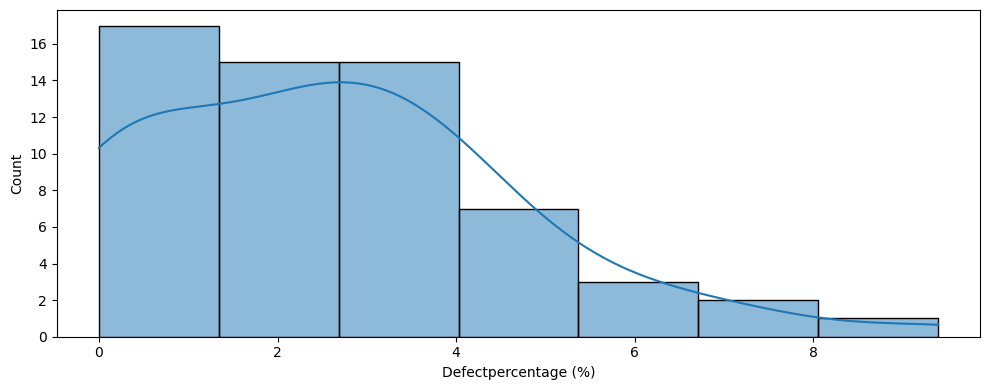

In [29]:
plt.figure(figsize=(10, 4))
sns.histplot(model_df[target], kde=True)
plt.tight_layout()


### 3.4  Verdeling van de features

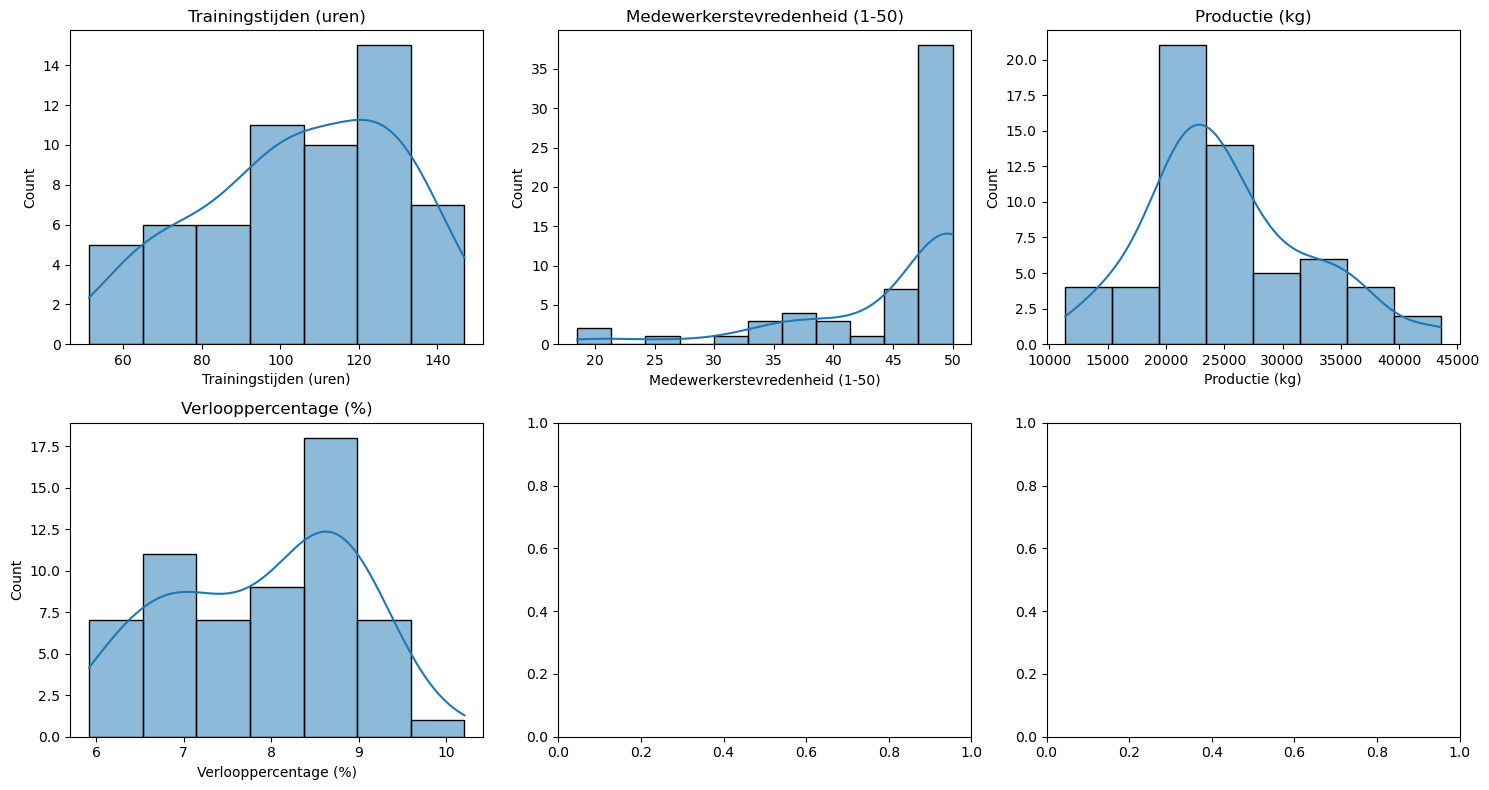

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, alle_features):
    sns.histplot(model_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()

### 3.5 Outlierdetectie (IQR)



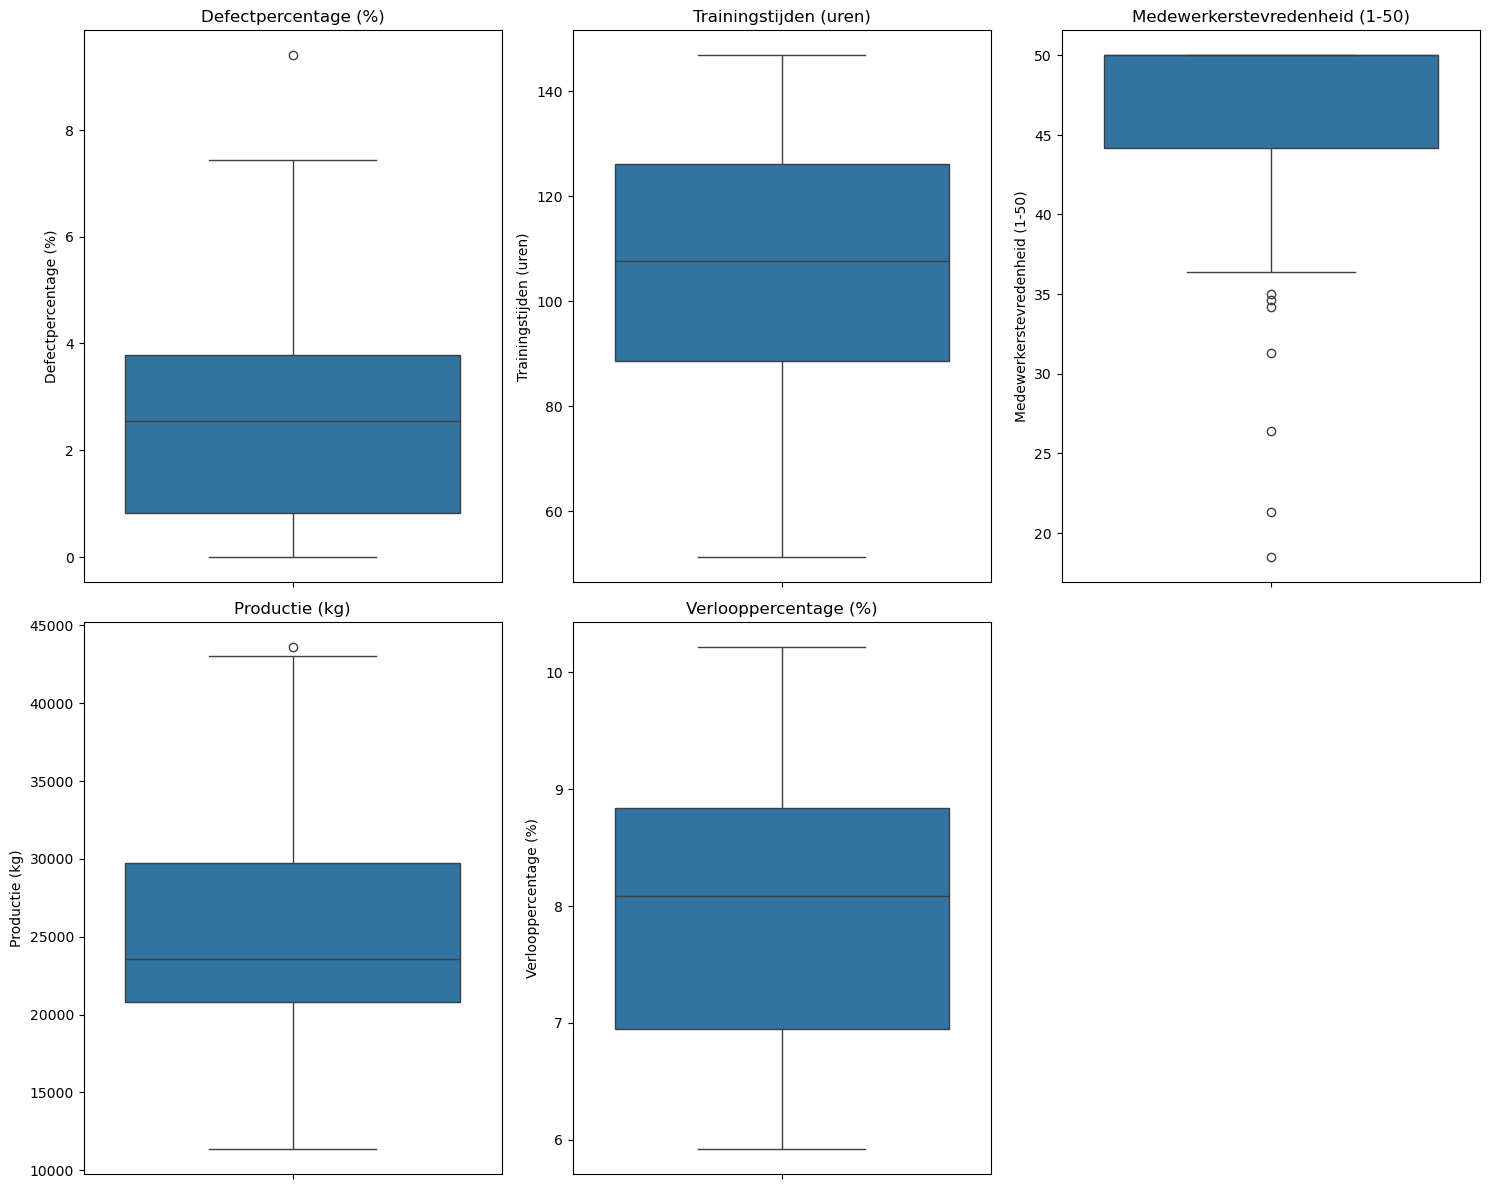

In [31]:
kolommen = [target] + alle_features

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, kolommen):
    sns.boxplot(y=model_df[col], ax=ax)
    ax.set_title(col)

for ax in axes.flat[len(kolommen):]:
    ax.axis("off")

plt.tight_layout()


In [32]:
for col in alle_features + [target]:
    q1, q3 = model_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    ondergrens, bovengrens = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((model_df[col] < ondergrens) | (model_df[col] > bovengrens)).sum()
    print(f"{col}: {n_outliers} outliers")


Trainingstijden (uren): 0 outliers
Medewerkerstevredenheid (1-50): 7 outliers
Productie (kg): 1 outliers
Verlooppercentage (%): 0 outliers
Defectpercentage (%): 1 outliers


### 3.6 Samenhang tussen features en target

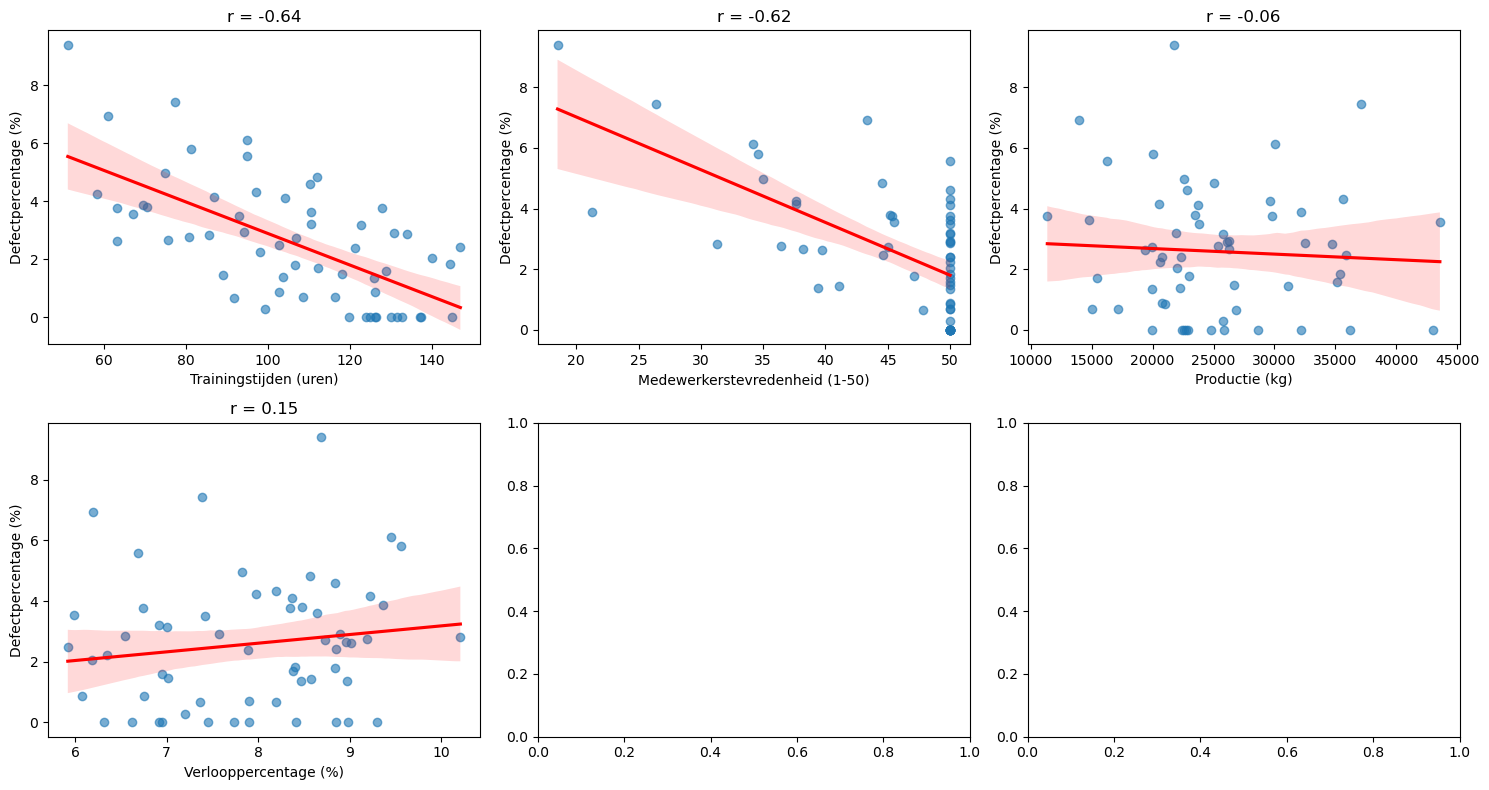

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, alle_features):
    sns.regplot(data=model_df, x=col, y=target, ax=ax,
                scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
    ax.set_title(f"r = {model_df[col].corr(model_df[target]):.2f}")
plt.tight_layout()

### 3.7 Correlatie tussen de features onderling



<Axes: >

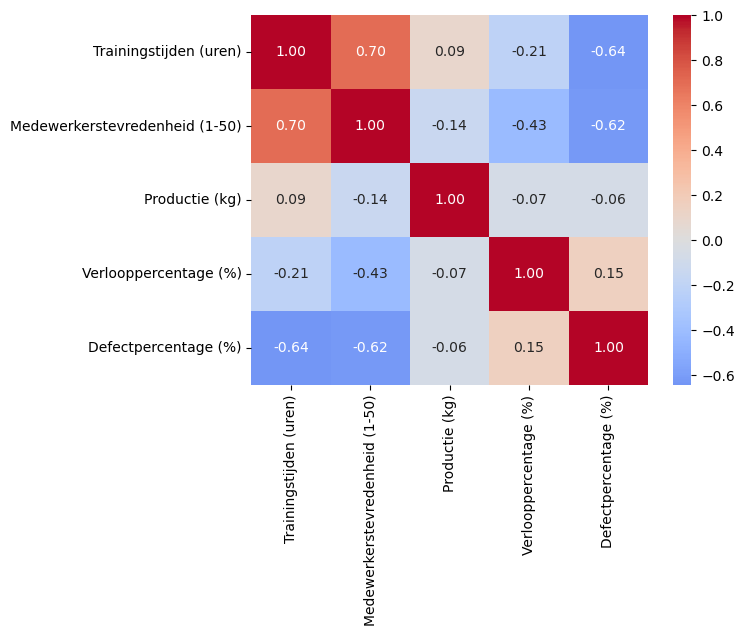

In [34]:
corr_matrix = model_df[alle_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")

### 3.8 Tijdreeks-patroon

Text(0.5, 1.0, 'Defectpercentage over tijd')

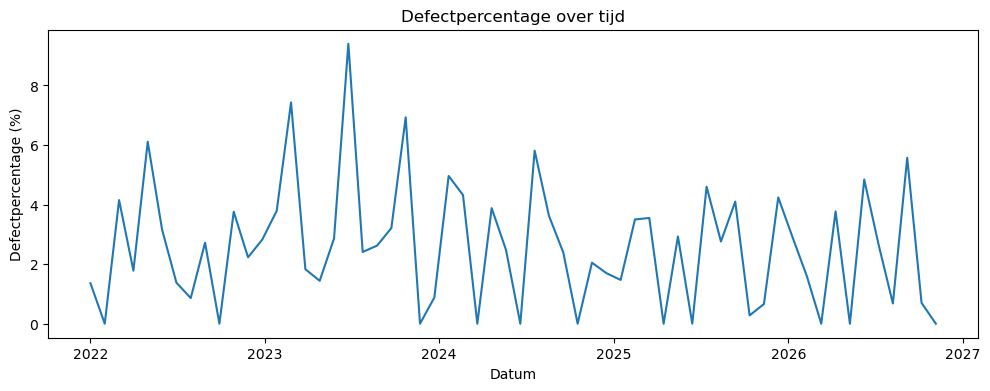

In [35]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=model_df, x="Datum", y=target)
plt.title("Defectpercentage over tijd")

### 3.9 Conclusie EDA

Samenvatting


## 4. Data voorbewerking (preprocessing)

## 5. Modelleren

## 6. Evalueren